In [5]:
import Pkg; Pkg.activate(dirname(@__DIR__))
using BullseyeFDFD
using BullseyeFDFD: _adjoint_setup, _solve_eig, _select_mode, _dk2_dp,
                    _fom_and_grad, evaluate_fom, material_tensors, _overlap
using LinearAlgebra, Printf, Statistics, Plots

  Activating project at `~/BullseyeFDFD/BullseyeFDFD/validation`


#### Helper Functions

In [ ]:

function width_labels(design)
    n = length(design)
    labs = Vector{String}(undef, n)
    labs[1] = "eye"; labs[n] = "buffer"
    ring = 0
    for i in 2:n-1
        iseven(i) ? (ring += 1; labs[i] = "trench $ring") : (labs[i] = "ring $ring")
    end
    return labs
end;

# Nominal Bullseye Design Setup

In [ ]:
const nClad = 1.0; 
const nSiN = 2.01066; 
const nSiO2 = 1.45375;
const nSi = 3.69476 - 1im*0.00482;

const substrates = [(n=nSiO2, height=0.75057), (n=nSi, height=Inf)];
const design = [0.355000,             # eye
                0.100000, 0.370000,   # trench 1, ring 1
                0.100000, 0.370000,   # trench 2, ring 2
                0.100000, 0.370000,   # trench 3, ring 3
                0.100000, 0.370000,   # trench 4, ring 4
                0.100000, 0.370000,   # trench 5, ring 5
                0.100000, 0.370000,   # trench 6, ring 6
                0.100000, 0.370000,   # trench 7, ring 7
                0.100000, 0.370000,   # trench 8, ring 8
                0.100000, 0.370000,   # trench 9, ring 9
                0.100000, 0.370000,   # trench 10, ring 10
                0.100000];            # buffer
const λ = 0.780; 
const tCBG = 0.17886;

const gridkw = (; λPts=20, geoPts=8, PMLρ=0.5, PMLz_bot=0.5, PMLz_top=0.5,
                  padρ=0.5, padz_bot=0.5, padz_top=0.5);

const TOL   = 1e-12;
const NMODES = 5;

const FOMs  = [λ_target(0.780), Q_target(:max)];

const lower = fill(0.05, length(design));
const upper = fill(1.00, length(design));

# Adjoint Calculation Setup

In [25]:
grid, M, εof = _adjoint_setup(design, substrates, nClad, nSiN, tCBG, false, λ, 1, gridkw);

function solve_modes(d)
    ϵ = εof(d); iϵ = material_tensors(ϵ, grid)[1]
    return _solve_eig(iϵ * M, grid, λ, NMODES, TOL, 5000), iϵ, ϵ
end;
track(modes, ref) = argmax(m -> _overlap(m.raw_E, ref), modes);

# Calculate the Gradient of the Nominal Design

mode: λ=780.00 nm  Q=354.4  k²=64.888232+0.183091im  (3N=291030)


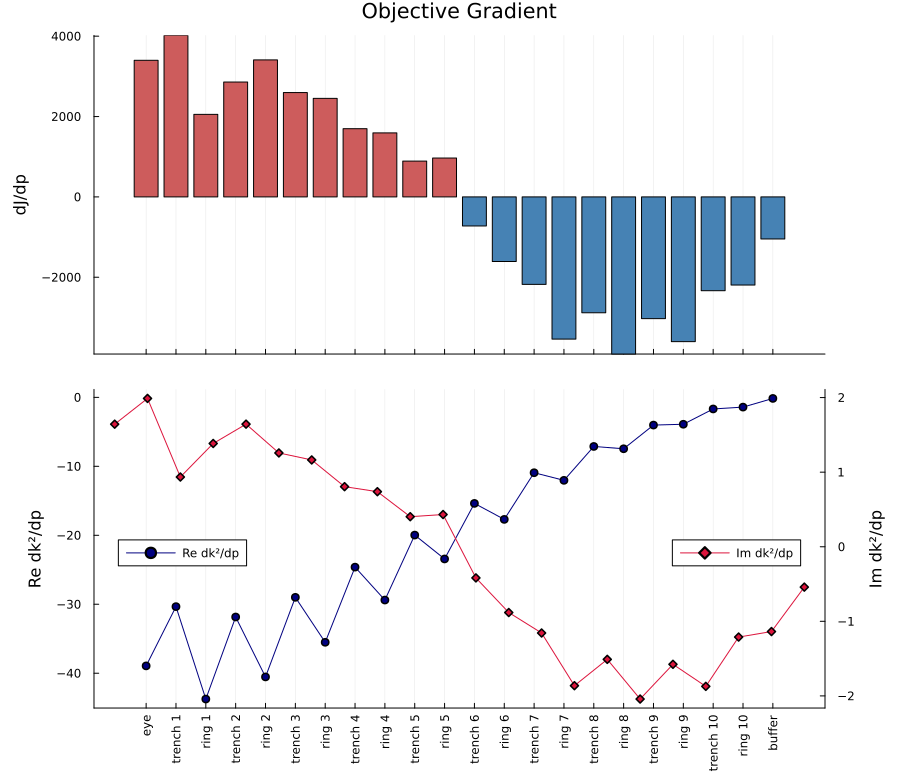

In [79]:
raw, iϵ, ϵ = solve_modes(design);
A  = iϵ * M;
rm = _select_mode(raw, λ, 0.020)
@printf("mode: λ=%.2f nm  Q=%.1f  k²=%.6f%+.6fim  (3N=%d)\n",
        rm.λ*1000, rm.Q, real(rm.k_sq), imag(rm.k_sq), 3grid.N);

dk2_adj, _    = _dk2_dp(design, rm, grid, A, iϵ, M, εof, rm.raw_E; δ=1e-7);
J0, dJ_adj, _ = _fom_and_grad(rm.k_sq, dk2_adj, FOMs);

labs = width_labels(design)
cols = [g ≥ 0 ? :indianred : :steelblue for g in dJ_adj]

n = length(design); x = 1:n

p1 = bar(x, dJ_adj; color=cols, legend=false, ylabel="dJ/dp", title="Objective Gradient",
         xticks=(x, fill("", n)))
plot!(twinx(p1), x, fill(NaN, n); legend=false, xticks=:none, yticks=:none,
      ylabel=" ", yshowaxis=false)

p2 = plot(x, real.(dk2_adj); marker=:circle, color=:navy,
          label="Re dk²/dp", ylabel="Re dk²/dp",
          legend=:left, xticks=(x, labs), xrotation=90)

plot!(twinx(p2), x, imag.(dk2_adj); marker=:diamond, color=:crimson,
      label="Im dk²/dp", ylabel="Im dk²/dp", legend=:right, xticks=:none)

plot(p1, p2; layout=(2,1), link=:x, size=(900, 780), left_margin=4Plots.mm, right_margin=5Plots.mm)

Since the resonance $\lambda$ is directly on target, the gradient here is purely driven by $Q$.
### $\frac{dJ}{dp}$
A positive value of $\frac{dJ}{dp}$ means the width should shrink, and a negative value of $\frac{dJ}{dp}$ means the width should grow.
The magnitude is an indication of how strongly the feature moves the FOM.
Note that our FOM is a fixed $\lambda$ and maximum $Q$ - different FOMs would change the gradient and how the features affect the gradient.
#### $\mathrm{Re}\left(\frac{dk_0^2}{dp}\right)$
From the theory notes, $\mathrm{Re}\left(\frac{dk_0^2}{dp}\right)$ mostly drives the resonance $\lambda$ so the plot is mostly telling us how each feature affects $\lambda$. It intuitively makes sense that the radius of the eye, trench 1, and ring 1 would affect it the most, and the buffer having almost no effect on it. Notice that every value of $\mathrm{Re}\left(\frac{dk_0^2}{dp}\right)$ is negative, which means growing __any__ width would redshift the resonance $\lambda$.
#### $\mathrm{Im}\left(\frac{dk_0^2}{dp}\right)$
From the theory notes, $\mathrm{Im}\left(\frac{dk_0^2}{dp}\right)$ mostly drives the optical quality factor $Q$ so the plot is mostly telling us how each feature affects $Q$ - it is not a coincidence that this plot looks a lot like the $\frac{dJ}{dp}$ plot.

In [80]:
function fd_at(k, δ)
    dp = copy(design); dp[k] = min(dp[k] + δ, upper[k])
    dm = copy(design); dm[k] = max(dm[k] - δ, lower[k])
    δa = (dp[k] - dm[k]) / 2
    mp = track(solve_modes(dp)[1], rm.raw_E)
    mm = track(solve_modes(dm)[1], rm.raw_E)
    k2_fd = (mp.k_sq - mm.k_sq) / (2δa)
    J_fd = (evaluate_fom(FOMs, Dict(:λ=>mp.λ, :Q=>mp.Q))[1] -
        evaluate_fom(FOMs, Dict(:λ=>mm.λ, :Q=>mm.Q))[1]) / (2δa)

    return k2_fd, J_fd
end;
relerr(a, b) = abs(a - b) / max(abs(b), 1e-12);

In [82]:
δs = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7]
println("\nδ_fd sweep — relative error vs. adjoint (over $(length(design)) params)")
@printf("%-9s | %-11s %-11s | %-11s %-11s\n", "δ_fd", "dk²/dp med", "dk²/dp max", "dJ/dp med", "dJ/dp max")
println("-"^60)
best_δ = δs[1]; best_med = Inf
for δ in δs
    ek = Float64[]; eJ = Float64[]
    for k in eachindex(design)
        k2fd, Jfd = fd_at(k, δ)
        push!(ek, relerr(dk2_adj[k], k2fd))
        push!(eJ, relerr(dJ_adj[k], Jfd))
    end
    mk = median(ek)
    @printf("%-9.0e | %-11.3e %-11.3e | %-11.3e %-11.3e\n", δ, mk, maximum(ek), median(eJ), maximum(eJ))
    if mk < best_med
        global best_med = mk
        global best_δ   = δ
    end
end
@printf("\nbest dk²/dp median relerr %.2e at δ_fd=%.0e\n", best_med, best_δ)


δ_fd sweep — relative error vs. adjoint (over 22 params)
δ_fd      | dk²/dp med  dk²/dp max  | dJ/dp med   dJ/dp max  
------------------------------------------------------------
1e-03     | 3.124e-03   1.836e-02   | 9.803e-03   1.518e-01  
1e-04     | 3.564e-04   2.601e-03   | 1.195e-03   1.825e-02  
1e-05     | 3.625e-05   2.714e-04   | 1.170e-04   1.863e-03  
1e-06     | 3.637e-06   2.727e-05   | 1.167e-05   1.867e-04  
1e-07     | 3.654e-07   2.732e-06   | 1.168e-06   1.863e-05  

best dk²/dp median relerr 3.65e-07 at δ_fd=1e-07


In [83]:
println("\nper-component agreement at δ_fd=$(best_δ):")
@printf("%3s | %-24s | %-24s | %-9s | %-9s\n", "k", "adjoint dk²/dp", "FD dk²/dp", "dk² err", "dJ err")
println("-"^86)
for k in eachindex(design)
    k2fd, Jfd = fd_at(k, best_δ)
    @printf("%3d | %+.5e%+.5ei | %+.5e%+.5ei | %.2e | %.2e\n", k,
            real(dk2_adj[k]), imag(dk2_adj[k]), real(k2fd), imag(k2fd),
            relerr(dk2_adj[k], k2fd), relerr(dJ_adj[k], Jfd))
end


per-component agreement at δ_fd=1.0e-7:
  k | adjoint dk²/dp           | FD dk²/dp                | dk² err   | dJ err   
--------------------------------------------------------------------------------------
  1 | -3.89383e+01+1.64326e+00i | -3.89383e+01+1.64329e+00i | 1.11e-06 | 1.31e-05
  2 | -3.03450e+01+1.98857e+00i | -3.03450e+01+1.98853e+00i | 2.73e-06 | 1.86e-05
  3 | -4.37456e+01+9.34805e-01i | -4.37456e+01+9.34809e-01i | 1.22e-07 | 1.17e-06
  4 | -3.18489e+01+1.38462e+00i | -3.18489e+01+1.38461e+00i | 7.70e-07 | 1.01e-05
  5 | -4.05380e+01+1.64387e+00i | -4.05380e+01+1.64387e+00i | 6.63e-08 | 4.25e-06
  6 | -2.89980e+01+1.25745e+00i | -2.89980e+01+1.25745e+00i | 1.85e-07 | 6.17e-06
  7 | -3.55168e+01+1.16376e+00i | -3.55168e+01+1.16376e+00i | 2.97e-08 | 2.31e-06
  8 | -2.46179e+01+8.05517e-01i | -2.46179e+01+8.05519e-01i | 2.12e-07 | 5.85e-07
  9 | -2.93909e+01+7.38097e-01i | -2.93909e+01+7.38098e-01i | 1.47e-07 | 1.16e-06
 10 | -1.99711e+01+4.02799e-01i | -1.99711e+01+4.028